# 02. Edge Detection

목표는 색칠 경계로 사용할 선을 추출하고, 흰 배경과 검은 선 형태의 컬러링북 선화를 만드는 것입니다.

비교 알고리즘:

- Sobel: x/y 방향 밝기 변화량을 계산합니다.
- Laplacian: 2차 미분 기반으로 급격한 변화 지점을 찾습니다.
- Canny: 노이즈 제거, 그래디언트, 비최대 억제, 이중 임계값을 함께 사용하는 대표적인 경계 추출 방식입니다.
- Hybrid Color Boundary: Canny가 놓치는 비슷한 밝기의 색상 경계를 보완합니다.

최종 기본 알고리즘은 Canny에 색상 라벨 경계를 합친 Hybrid 방식입니다.

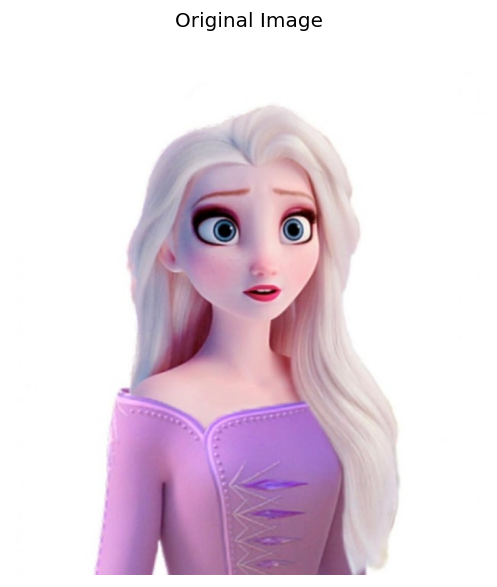

In [2]:
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

# 결과 저장 폴더(outputs)와 샘플 입력 폴더(data)를 생성합니다.
ensure_dirs()
plt.rcParams["figure.dpi"] = 120

# 직접 사용할 이미지가 있으면 여기에 경로를 넣으세요.
# 예: IMAGE_PATH = "../data/flowers.jpg"
IMAGE_PATH = "../data/elsa.jpeg"
if not IMAGE_PATH or not os.path.exists(IMAGE_PATH):
    print(f"WARNING: '{IMAGE_PATH}' not found, using built-in sample image instead.")
    IMAGE_PATH = None

try:
    image = load_image(IMAGE_PATH)
except FileNotFoundError as exc:
    print(f"WARNING: {exc}; using built-in sample image instead.")
    image = load_image(None)

show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 경계 추출 비교

먼저 K-Means로 색상을 단순화한 뒤 경계를 추출하면 원본의 작은 질감 노이즈가 줄어듭니다.

In [ ]:
# 경계선 추출 전에 색상을 단순화하면 원본 텍스처 노이즈가 줄어듭니다.
K = 10
# Use existing helper if available, otherwise fall back to OpenCV k-means
if callable(globals().get("kmeans_quantization_with_labels")):
    quantized, palette, label_map = kmeans_quantization_with_labels(image, K)
else:
    Z = image.reshape(-1, 3).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    centers = np.clip(centers, 0, 255).astype(np.uint8)
    quantized = centers[labels.flatten()].reshape(image.shape)
    label_map = labels.reshape(image.shape[:2]).astype(np.int32)
    palette = centers

# Sobel: x/y 방향 밝기 변화량을 이용해 경계를 찾습니다.
(sobel, sobel_time) = timed_call(sobel_edges, quantized, 65)

# Laplacian: 2차 미분으로 급격한 밝기 변화를 찾습니다.
(laplacian, lap_time) = timed_call(laplacian_edges, quantized, 25)

# Canny: 노이즈 제거, 비최대 억제, 이중 임계값을 사용하는 기본 선택 알고리즘입니다.
(canny, canny_time) = timed_call(canny_edges, quantized, 60, 150)

# Color Boundary: K-Means 대표 색상 라벨이 바뀌는 지점을 경계로 추가합니다.
# 밝기는 비슷하지만 색상이 다른 겹친 영역을 분리하는 데 중요합니다.
(hybrid, hybrid_time) = timed_call(hybrid_canny_color_edges, quantized, 60, 150, label_map)

# Opening은 작은 점 노이즈 제거, Closing은 끊긴 선 연결에 사용합니다.
sobel_clean = clean_edges(sobel, open_iter=1, close_iter=1, thickness=1)
lap_clean = clean_edges(laplacian, open_iter=1, close_iter=1, thickness=1)
canny_clean = clean_edges(canny, open_iter=0, close_iter=1, thickness=2)
hybrid_clean = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=1)

save_image_rgb("flowersoutput/02_sobel_lines.png", coloring_line_image(sobel_clean))
save_image_rgb("flowersoutput/02_laplacian_lines.png", coloring_line_image(lap_clean))
save_image_rgb("flowersoutput/02_canny_lines.png", coloring_line_image(canny_clean))
save_image_rgb("flowersoutput/02_hybrid_color_boundary_lines.png", coloring_line_image(hybrid_clean))

show_images([
    ("Quantized Input", quantized),
    (f"Sobel density={edge_density(sobel_clean):.3f}", coloring_line_image(sobel_clean)),
    (f"Laplacian density={edge_density(lap_clean):.3f}", coloring_line_image(lap_clean)),
    (f"Canny density={edge_density(canny_clean):.3f}", coloring_line_image(canny_clean)),
    (f"Hybrid density={edge_density(hybrid_clean):.3f}", coloring_line_image(hybrid_clean)),
], cols=2, figsize=(11, 10), cmap="gray", save_path="flowersoutput/02_edge_compare.png")

NameError: name 'kmeans_quantization_with_labels' is not defined

## 선 두께와 Morphology 조절

`thickness`, `open_iter`, `close_iter` 값을 바꾸면 번호 삽입과 색칠 난이도에 맞춰 선을 조절할 수 있습니다.

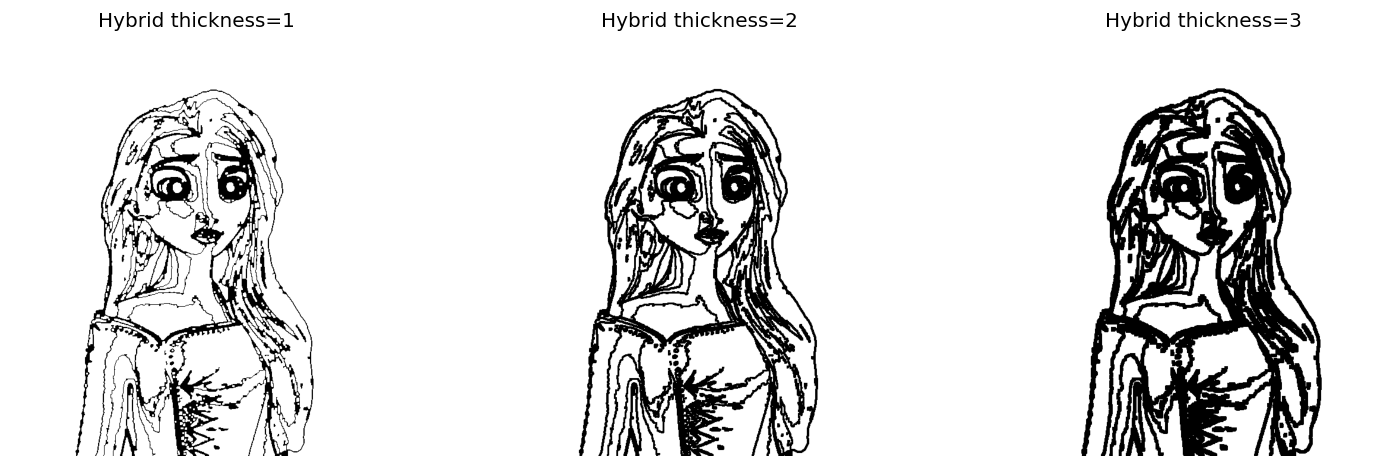

In [3]:
variants = []
for thickness in [1, 2, 3]:
    # thickness가 커질수록 선은 잘 보이지만 색칠 가능한 흰 영역은 줄어듭니다.
    adjusted = clean_edges(hybrid, open_iter=0, close_iter=1, thickness=thickness)
    variants.append((f"Hybrid thickness={thickness}", coloring_line_image(adjusted)))
    save_image_rgb(f"flowersoutput/02_hybrid_thickness_{thickness}.png", coloring_line_image(adjusted))

show_images(variants, cols=3, figsize=(13, 4), cmap="gray", save_path="flowersoutput/02_thickness_compare.png")

## 성능 비교 표

Edge Density는 전체 픽셀 중 경계 픽셀이 차지하는 비율입니다. 너무 낮으면 선이 끊기고, 너무 높으면 색칠 공간이 좁아집니다.

In [4]:
edge_rows = [
    {"algorithm": "Sobel", "runtime_sec": sobel_time, "edge_density": edge_density(sobel_clean), "hci_note": "두꺼운 변화 감지, 질감 노이즈 주의"},
    {"algorithm": "Laplacian", "runtime_sec": lap_time, "edge_density": edge_density(lap_clean), "hci_note": "세부 변화 민감, 작은 노이즈 많음"},
    {"algorithm": "Canny", "runtime_sec": canny_time, "edge_density": edge_density(canny_clean), "hci_note": "선명도와 노이즈 균형 우수"},
    {"algorithm": "Hybrid Color Boundary", "runtime_sec": hybrid_time, "edge_density": edge_density(hybrid_clean), "hci_note": "비슷한 밝기의 색상 경계까지 분리"},
]
print_table(edge_rows)

algorithm             | runtime_sec | edge_density | hci_note            
----------------------+-------------+--------------+---------------------
Sobel                 | 0.0093      | 0.1881       | 두꺼운 변화 감지, 질감 노이즈 주의
Laplacian             | 0.0039      | 0.0531       | 세부 변화 민감, 작은 노이즈 많음 
Canny                 | 0.0027      | 0.2602       | 선명도와 노이즈 균형 우수      
Hybrid Color Boundary | 0.0066      | 0.4441       | 비슷한 밝기의 색상 경계까지 분리  


## 비교 분석

- 선 명확도: Canny가 끊김이 적고 외곽선이 비교적 안정적입니다.
- 노이즈: Laplacian은 작은 밝기 변화에도 민감해 노이즈가 많을 수 있습니다.
- 처리 속도: 세 방법 모두 빠르지만 Sobel/Laplacian이 단순하고 Canny가 약간 더 많은 단계를 가집니다.
- 컬러링북 적합성: Canny + Color Boundary + Closing + 적당한 Dilate 조합이 겹친 색상 영역까지 분리해 가장 적합합니다.